In [1]:
from sklearn.model_selection import train_test_split

In [2]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson')
gdf = gpd.read_file(data_path)

In [3]:
gdf 

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,poly_id,image_uid,r_mean,r_std,g_mean,g_std,b_mean,b_std,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,34429.374,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,0,img_0000_c4a77f3e,67.118672,63.050778,72.369456,65.615000,50.007945,48.514536,"MULTIPOLYGON (((-72.97056 10.61903, -72.97054 ..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,6784.769,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1,img_0000_c4a77f3e,86.838321,65.381449,76.577952,58.398020,63.137208,49.598628,"MULTIPOLYGON (((-72.96914 10.61884, -72.96915 ..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12227.436,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,2,img_0000_c4a77f3e,57.903879,54.918250,74.354503,66.705400,39.715053,44.734299,"MULTIPOLYGON (((-72.96928 10.61948, -72.96931 ..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,19385.187,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,3,img_0000_c4a77f3e,102.817986,53.979692,107.550803,51.629908,70.705621,42.725916,"MULTIPOLYGON (((-72.97264 10.61976, -72.97273 ..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5013.914,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,4,img_0000_c4a77f3e,32.369521,45.569768,42.636383,57.399349,21.679273,32.445704,"MULTIPOLYGON (((-72.96917 10.62053, -72.9691 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1948,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1528.937,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1948,img_0029_37df798b,31.018763,45.725327,36.589655,52.510946,18.985246,29.199369,"MULTIPOLYGON (((-75.123 3.80901, -75.12297 3.8..."
1949,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1949,img_0029_37df798b,0.089548,2.602153,0.102208,2.904781,0.059827,1.799307,"MULTIPOLYGON (((-75.12391 3.81075, -75.1239 3...."
1950,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10536.989,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1950,img_0029_37df798b,30.101152,37.576581,33.759418,39.037403,19.319645,26.745836,"MULTIPOLYGON (((-75.12278 3.8104, -75.12282 3...."
1951,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5139.198,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1951,img_0029_37df798b,50.930026,41.676151,50.996732,40.269621,32.692476,29.041893,"MULTIPOLYGON (((-75.12367 3.81079, -75.12357 3..."


In [4]:
gdf.columns

Index(['CODIGO', 'OBSERV', 'INSUMO', 'APOYO', 'ASIGNACION', 'Asignado', 'OAM',
       'area', 'url_type', 'download_url', 'poly_id', 'image_uid', 'r_mean',
       'r_std', 'g_mean', 'g_std', 'b_mean', 'b_std', 'geometry'],
      dtype='object')

In [5]:
na_count = gdf['OBSERV'].isna().sum()
print(f"Number of NA values in 'OBSERV' column: {na_count}")


Number of NA values in 'OBSERV' column: 1


#### Cleanup : 
Lets drop the null rows which dont have labels 

In [6]:
gdf = gdf.dropna(subset=['OBSERV'])

In [7]:
print(gdf['OBSERV'].value_counts())

OBSERV
building                        683
clean pasture                   320
dense forest                    155
Bare areas                      145
urban not continuous            142
weedy pasture                   128
wooded pasture                   64
permanent crops                  57
fragmented forest                56
seasonal crops                   42
highway                          33
rivers                           21
urban                            17
Open forest                      17
lakes                            14
Secondary vegetation             14
Open grassland                   13
Shrubland                        10
Sandy areas                       6
Burnt areas                       4
comercial or industrial area      4
canals                            3
Dense grassland                   3
forest                            1
Name: count, dtype: int64


#### Cleanup : 
since we observed that those are the last categories with <10 features hence we will drop them because they are too small no of samples for model to generalize 

In [8]:
classes_to_remove = ['Sandy areas','Burnt areas','Dense grassland','comercial or industrial area', 'canals', 'forest']

gdf = gdf[~gdf['OBSERV'].isin(classes_to_remove)]

In [9]:
print(gdf['OBSERV'].value_counts())

OBSERV
building                683
clean pasture           320
dense forest            155
Bare areas              145
urban not continuous    142
weedy pasture           128
wooded pasture           64
permanent crops          57
fragmented forest        56
seasonal crops           42
highway                  33
rivers                   21
Open forest              17
urban                    17
lakes                    14
Secondary vegetation     14
Open grassland           13
Shrubland                10
Name: count, dtype: int64


In [10]:
len(gdf)

1931

In [25]:
gdf['area'] = gdf.to_crs(3857).geometry.area

### Train Split : 

We will use **stratify** , because we care about the distribution in class , just to make sure the class distribution is there in the test set as well 

train set distribution:
OBSERV
building                546
clean pasture           256
dense forest            124
Bare areas              116
urban not continuous    113
weedy pasture           102
wooded pasture           51
permanent crops          46
fragmented forest        45
seasonal crops           34
highway                  26
rivers                   17
urban                    14
Open forest              14
lakes                    11
Secondary vegetation     11
Open grassland           10
Shrubland                 8
Name: count, dtype: int64

 test distribution:
OBSERV
building                137
clean pasture            64
dense forest             31
urban not continuous     29
Bare areas               29
weedy pasture            26
wooded pasture           13
fragmented forest        11
permanent crops          11
seasonal crops            8
highway                   7
rivers                    4
urban                     3
Secondary vegetation      3
Open grassland     

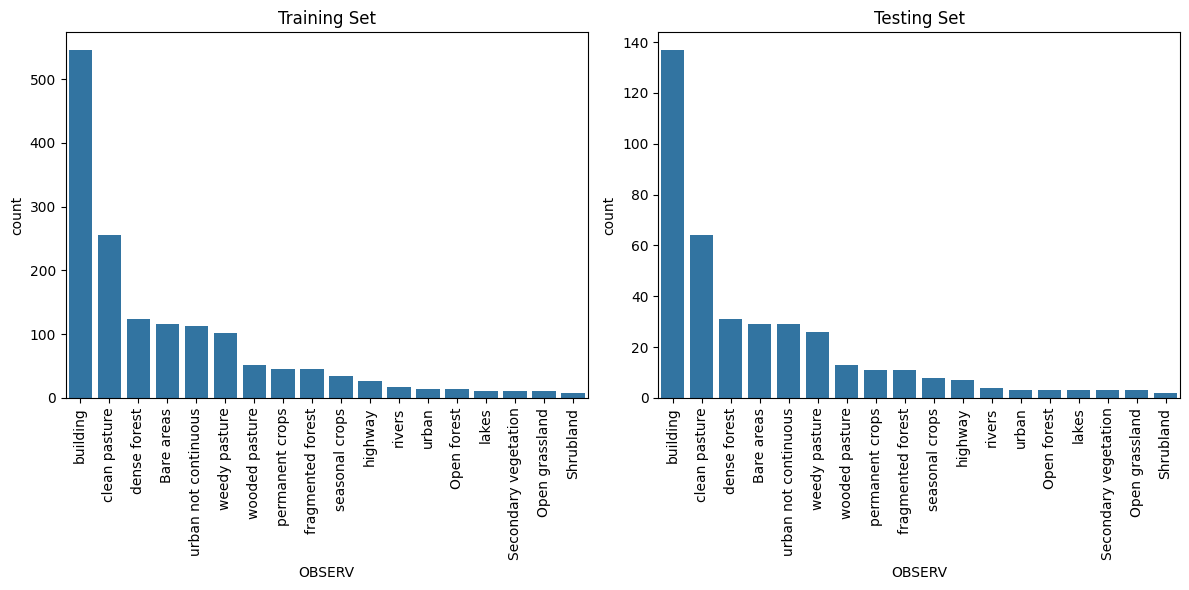

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'OBSERV'
features = ['r_mean', 'r_std', 'g_mean', 'g_std', 'b_mean', 'b_std','area']


train_gdf, test_gdf = train_test_split(gdf, test_size=0.2, random_state=42, stratify=gdf[target])

print("train set distribution:")
print(train_gdf[target].value_counts())
print("\n test distribution:")
print(test_gdf[target].value_counts())


class_order = train_gdf[target].value_counts().index

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(x=target, data=train_gdf, ax=ax[0], order=class_order)
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Training Set")

sns.countplot(x=target, data=test_gdf, ax=ax[1], order=class_order)
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Testing Set")

plt.tight_layout()
plt.show()

### Feature Analysis

Before training, let's analyze our feature distributions and relationships.

In [27]:
print("Feature Statistics:")
print(train_gdf[features].describe())

Feature Statistics:
            r_mean        r_std       g_mean        g_std       b_mean  \
count  1534.000000  1534.000000  1534.000000  1534.000000  1534.000000   
mean     73.010049    64.291898    76.649205    65.621732    60.625912   
std      43.524257    22.668509    43.018331    21.643028    44.860152   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%      41.768167    47.808136    46.042011    51.837897    28.736565   
50%      62.587167    63.134867    66.985639    65.236294    46.337351   
75%      97.791538    79.578163   102.959103    79.203366    79.169117   
max     223.151924   121.873455   225.930395   121.519517   235.247755   

             b_std          area  
count  1534.000000  1.544000e+03  
mean     55.805117  1.448897e+04  
std      25.664750  6.438438e+04  
min       0.000000  2.630270e-02  
25%      35.542529  1.311920e+02  
50%      50.119135  9.534029e+02  
75%      72.756827  5.772077e+03  
max     121.694937  1.206408e+06 

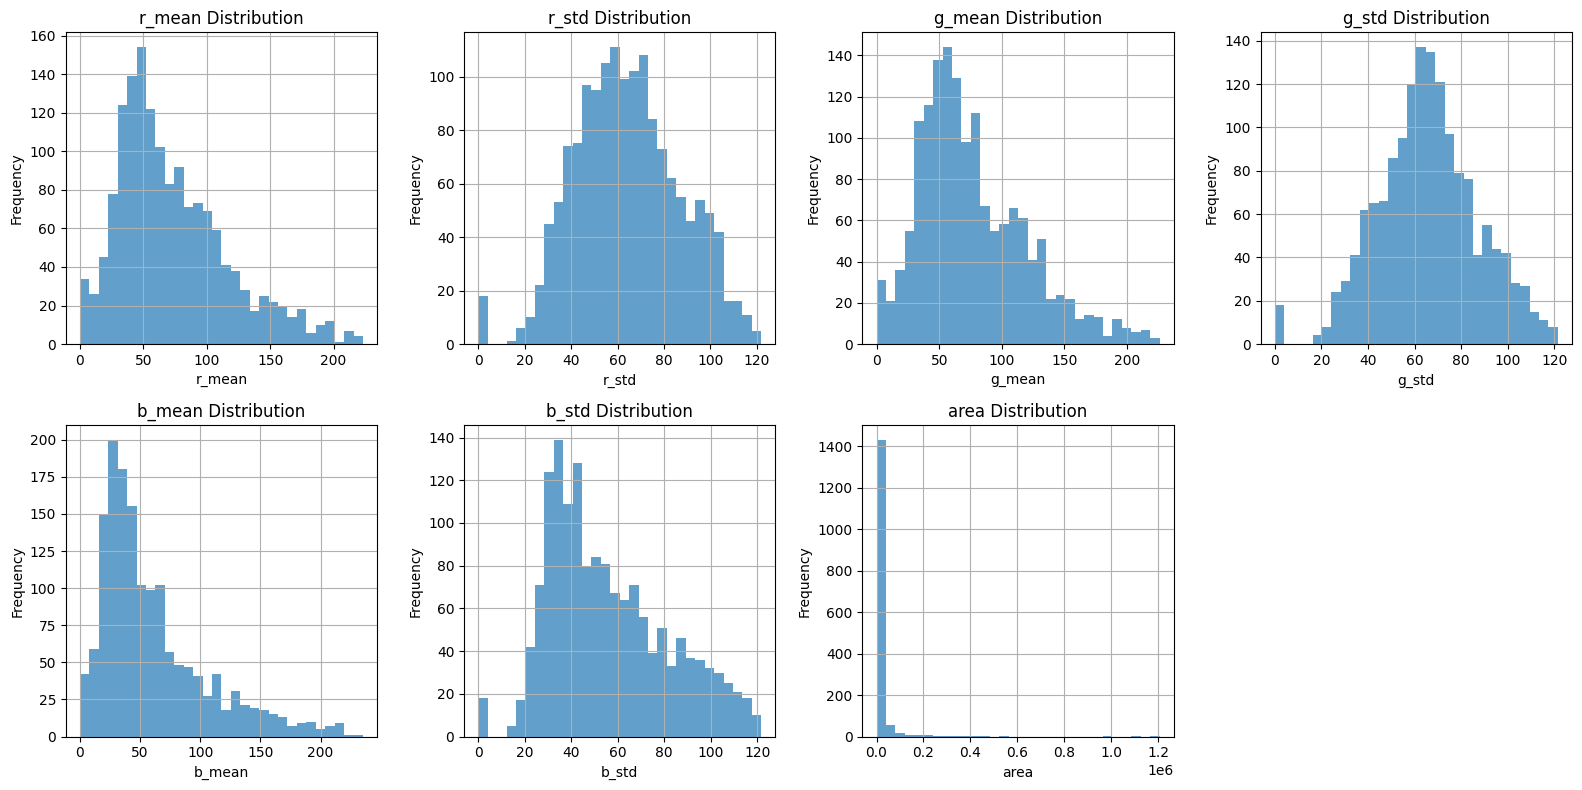

In [28]:
# feature distributions : histograms 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feature in enumerate(features):
    train_gdf[feature].hist(bins=30, ax=axes[i], alpha=0.7)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

axes[7].set_visible(False)
plt.tight_layout()
plt.show()

#### Understanding the Feature Analysis Graphs:

**1. Feature Statistics Table** - Shows basic numbers for each feature:
- `mean`: Average value 
- `std`: How spread out the values are (higher = more variation)
- `min/max`: Range of values
- `25%, 50%, 75%`: Quartiles (50% is median)

**2. Histograms** - Show the shape of data distribution:
- **Normal bell curve**: Most values around the middle (good for ML)
- **Skewed**: Most values bunched to one side (might need transformation)
- **Multiple peaks**: Different groups in your data
- **Outliers**: Bars far from the main group

**3. Correlation Matrix** - Shows how features relate to each other:
- **Red (positive)**: When one feature increases, the other increases
- **Blue (negative)**: When one increases, the other decreases  
- **White (near 0)**: No relationship
- **Values close to 1 or -1**: Strong relationship (might be redundant features)

**4. Pairplot** - Scatter plots between every pair of features:
- **Diagonal**: Histograms of each feature
- **Off-diagonal**: Scatter plots showing relationships
- **Colors**: Different land cover classes
- **Good separation**: Different classes cluster separately (good for classification)
- **Overlapping clouds**: Classes mixed together (harder to classify)

Let's run these and I'll explain what we see in your specific data:

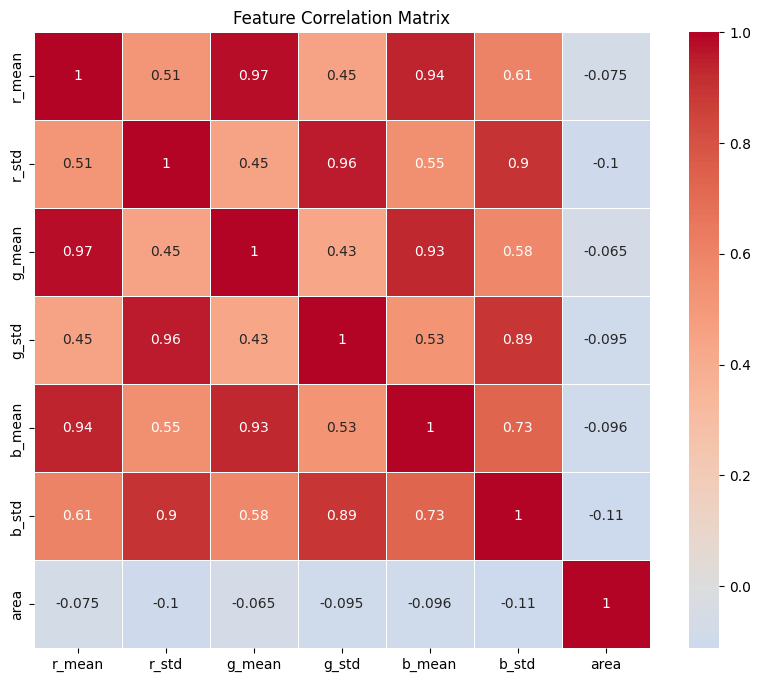

In [29]:
# correlation 
plt.figure(figsize=(10, 8))
correlation_matrix = train_gdf[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

### observation : 

here correlation between r_mean and g_mean is very high : almost identical , similar to r_mean and b_mean . All RGB bands are highly redundant , i don't think they are providing much value , area is extremely crucial information , it has low correlation as compared to other , perhaps we need to find more on gemetric or lookinto HSV , LAB colors ? other statstics that can disguinsh them properly or only using some of them or using some vegetation indexes 

In [ ]:
test_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))

In [13]:
train_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

### Spatially Stratified Sampling ?? 

We think as there are features spatially correlated , may be worth doing the spatial stratified sampling 

/tmp/ipykernel_789673/1549348063.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_gdf_gpd['x'] = train_gdf_gpd.geometry.centroid.x
/tmp/ipykernel_789673/1549348063.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_gdf_gpd['y'] = train_gdf_gpd.geometry.centroid.y
/tmp/ipykernel_789673/1549348063.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  test_gdf_gpd['x'] = test_gdf_gpd.geometry.centroid.x
/tmp/ipykernel_789673/1549348063.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' 

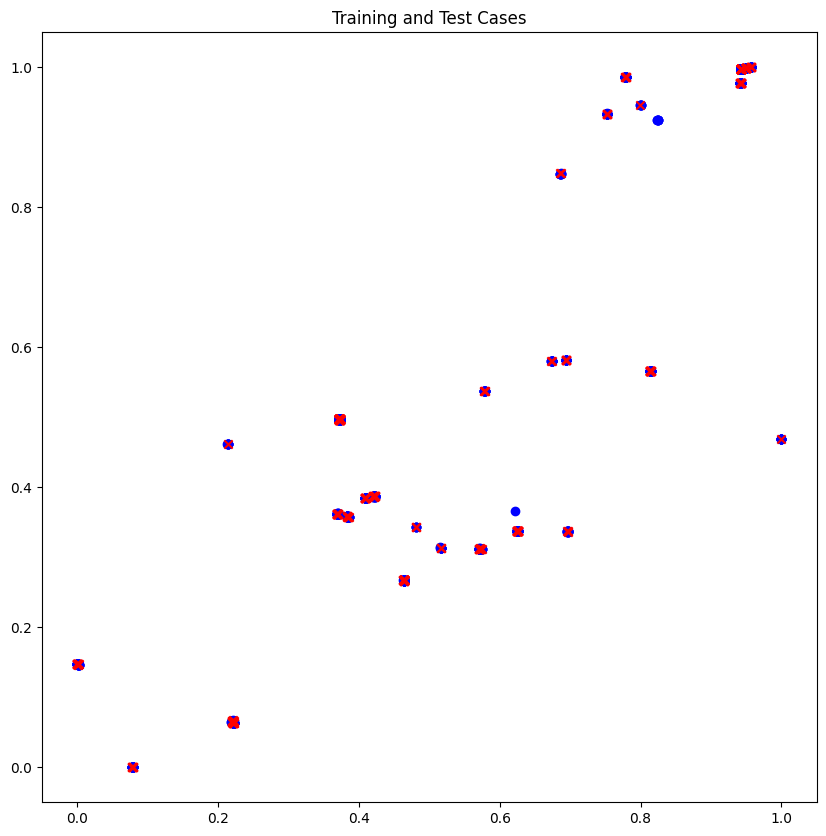

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

train_gdf_gpd = gpd.GeoDataFrame(train_gdf, geometry=train_gdf['geometry'])
test_gdf_gpd = gpd.GeoDataFrame(test_gdf, geometry=test_gdf['geometry'])

# Normalize the coordinates
train_gdf_gpd['x'] = train_gdf_gpd.geometry.centroid.x
train_gdf_gpd['y'] = train_gdf_gpd.geometry.centroid.y
test_gdf_gpd['x'] = test_gdf_gpd.geometry.centroid.x
test_gdf_gpd['y'] = test_gdf_gpd.geometry.centroid.y

x_min, x_max = min(train_gdf_gpd['x'].min(), test_gdf_gpd['x'].min()), max(train_gdf_gpd['x'].max(), test_gdf_gpd['x'].max())
y_min, y_max = min(train_gdf_gpd['y'].min(), test_gdf_gpd['y'].min()), max(train_gdf_gpd['y'].max(), test_gdf_gpd['y'].max())

train_gdf_gpd['x_norm'] = (train_gdf_gpd['x'] - x_min) / (x_max - x_min)
train_gdf_gpd['y_norm'] = (train_gdf_gpd['y'] - y_min) / (y_max - y_min)
test_gdf_gpd['x_norm'] = (test_gdf_gpd['x'] - x_min) / (x_max - x_min)
test_gdf_gpd['y_norm'] = (test_gdf_gpd['y'] - y_min) / (y_max - y_min)

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(train_gdf_gpd['x_norm'], train_gdf_gpd['y_norm'], color='blue', marker='o')
ax.scatter(test_gdf_gpd['x_norm'], test_gdf_gpd['y_norm'], color='red', marker='x')

ax.set_title("Training and Test Cases")

plt.show()
